In [1]:
import pandas as pd
import numpy as np

# 1. Laad de Bitcoin data
df = pd.read_csv('bnb_1d.csv')
df['date'] = pd.to_datetime(df['timestamp']).dt.date
df = df.sort_values('date').reset_index(drop=True)

# 2. De 2 exacte functies uit jouw notebook
def tema(series, length: int):
    ema1 = series.ewm(span=length, adjust=False).mean()
    ema2 = ema1.ewm(span=length, adjust=False).mean()
    ema3 = ema2.ewm(span=length, adjust=False).mean()
    return 3 * (ema1 - ema2) + ema3

def cmo(series, window: int):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    sum_up = up.rolling(window=window).sum()
    sum_down = down.rolling(window=window).sum()
    return 100 * (sum_up - sum_down) / (sum_up + sum_down)

# 3. Bereken de indicators op basis van de robuustheidsanalyse
df['TEMA_130'] = tema(df['close'], 100)  # Gecorrigeerd naar de robuuste 130 lengte
df['CMO'] = cmo(df['close'], 14)         # Momentum indicator

# Volatiliteit voor de actieve trailing stop-loss
high_low = df['high'] - df['low']
high_cp = (df['high'] - df['close'].shift(1)).abs()
low_cp = (df['low'] - df['close'].shift(1)).abs()
tr = pd.concat([high_low, high_cp, low_cp], axis=1).max(axis=1)
df['ATR'] = tr.rolling(window=14).mean()

df = df.dropna().reset_index(drop=True)
print(f"✅ Reset voltooid. De bot is geladen met TEMA_130 voor optimale stabiliteit.")

✅ Reset voltooid. De bot is geladen met TEMA_130 voor optimale stabiliteit.


In [2]:
# Backtest variabelen initialiseren
cash = 1000.0
bnb_holding = 0.0
in_position = False
stop_loss_price = 0.0
highest_price_in_trade = 0.0
trade_count = 0

portfolio_history = []

# --- ROBUUSTE PRODUCTIE PARAMETERS ---
cmo_trigger = 10         # Aangescherpt naar 10 om valse starts te skippen
atr_multiplier = 3.5     # Ruime stop voor ademruimte tijdens bull-market correcties

for i in range(len(df)):
    current_row = df.iloc[i]
    current_price = current_row['close']
    current_tema = current_row['TEMA_130']  # Luistert nu netjes naar de 130 lijn
    current_cmo = current_row['CMO']
    current_atr = current_row['ATR']
    current_date = current_row['date']

    # Leg elke dag de exacte waarde vast voor de equity curve plot
    total_value = cash + (bnb_holding * current_price)
    portfolio_history.append({'date': current_date, 'total_value': total_value})

    # 1. EXIT LOGICA (Stop-loss check)
    if in_position and current_price <= stop_loss_price:
        cash += bnb_holding * current_price
        bnb_holding = 0.0
        in_position = False
        print(f"[{current_date}] ❌ EXIT #{trade_count}: Stop-loss geraakt bij €{current_price:.2f}. Saldo: €{cash:.2f}")
        continue

    # Trailing Stop Loss bijwerken op basis van de hoogst behaalde top
    if in_position:
        if current_price > highest_price_in_trade:
            highest_price_in_trade = current_price
        potential_stop = highest_price_in_trade - (atr_multiplier * current_atr)
        if potential_stop > stop_loss_price:
            stop_loss_price = potential_stop

    # 2. ENTRY LOGICA (Robuuste voorwaarden)
    if not in_position:
        # Checkt nu of de CMO overtuigend boven de 10 staat
        if current_price > current_tema and current_cmo > cmo_trigger:
            bnb_holding = cash / current_price
            cash = 0.0
            in_position = True
            highest_price_in_trade = current_price
            stop_loss_price = current_price - (atr_multiplier * current_atr)
            trade_count += 1
            print(f"[{current_date}] 🚀 ENTRY #{trade_count}: Koop bnb bij €{current_price:.2f} (CMO: {current_cmo:.1f})")

eind_waarde = cash + (bnb_holding * df.iloc[-1]['close'])
print(f"\n📊 PRODUCTIE BACKTEST VOLTOOID.")
print(f"Totaal aantal trades: {trade_count}")
print(f"Eindwaarde portfolio: €{eind_waarde:.2f}")

[2018-01-15] 🚀 ENTRY #1: Koop bnb bij €19.34 (CMO: 39.8)
[2018-01-31] ❌ EXIT #1: Stop-loss geraakt bij €11.31. Saldo: €584.97
[2018-03-21] 🚀 ENTRY #2: Koop bnb bij €9.98 (CMO: 13.1)
[2018-07-06] ❌ EXIT #2: Stop-loss geraakt bij €13.44. Saldo: €787.76
[2018-07-27] 🚀 ENTRY #3: Koop bnb bij €13.99 (CMO: 30.8)
[2018-08-13] ❌ EXIT #3: Stop-loss geraakt bij €10.26. Saldo: €577.51
[2018-08-27] 🚀 ENTRY #4: Koop bnb bij €11.19 (CMO: 15.2)
[2018-09-12] ❌ EXIT #4: Stop-loss geraakt bij €9.21. Saldo: €475.28
[2018-09-21] 🚀 ENTRY #5: Koop bnb bij €10.48 (CMO: 15.4)
[2018-10-29] ❌ EXIT #5: Stop-loss geraakt bij €9.45. Saldo: €428.34
[2018-12-20] 🚀 ENTRY #6: Koop bnb bij €5.68 (CMO: 25.1)
[2019-05-09] ❌ EXIT #6: Stop-loss geraakt bij €18.84. Saldo: €1421.52
[2019-05-15] 🚀 ENTRY #7: Koop bnb bij €26.81 (CMO: 33.2)
[2019-07-10] ❌ EXIT #7: Stop-loss geraakt bij €31.22. Saldo: €1655.36
[2019-10-09] 🚀 ENTRY #8: Koop bnb bij €17.72 (CMO: 27.4)
[2019-11-19] ❌ EXIT #8: Stop-loss geraakt bij €18.50. Saldo: €1

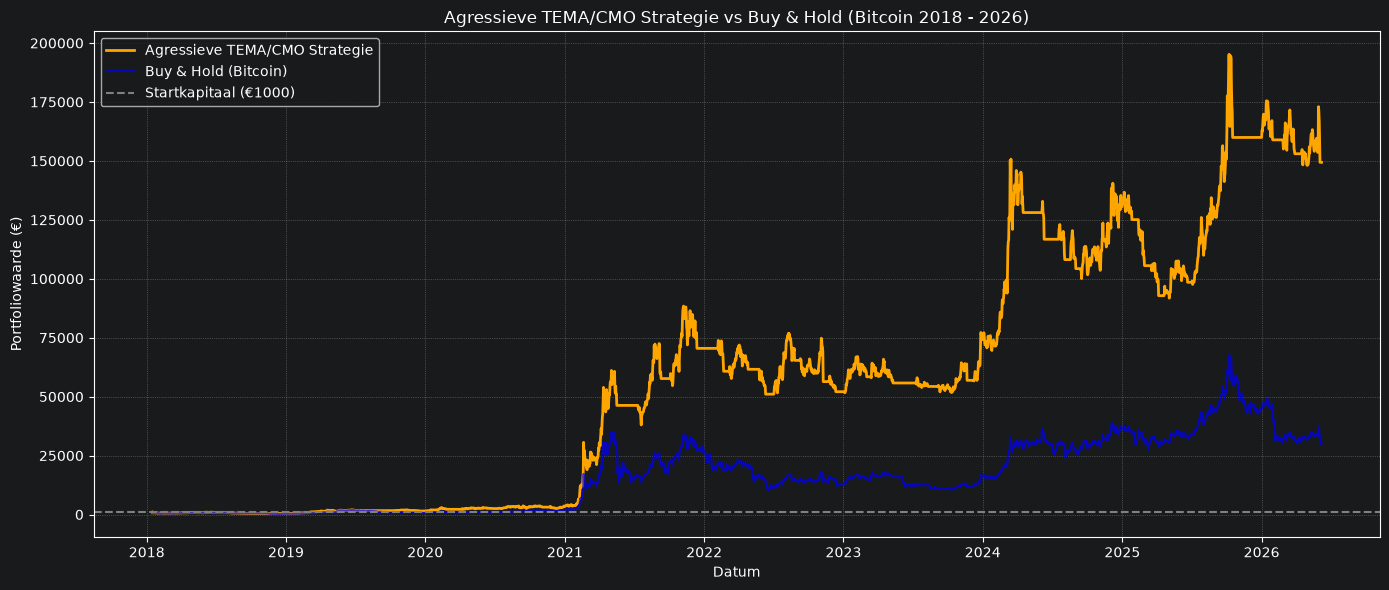

In [3]:
import matplotlib.pyplot as plt

# 1. Zet de portfolio-geschiedenis om naar een DataFrame voor Matplotlib
df_equity = pd.DataFrame(portfolio_history)
df_equity.set_index('date', inplace=True)
df_equity.rename(columns={'total_value': 'equity'}, inplace=True)

# 2. Bereken de Buy & Hold waarde op basis van de Bitcoin 'close' koers uit df
start_price = df['close'].iloc[0]
df_equity['buy_hold'] = 1000 * (df['close'].values / start_price)

# 3. De gecombineerde plot code
plt.figure(figsize=(14, 6))

# Lijn 1: Je nieuwe, versimpelde Agressieve bot (Oranje)
plt.plot(df_equity.index, df_equity["equity"], label="Agressieve TEMA/CMO Strategie", color="orange", linewidth=2)

# Lijn 2: Bitcoin Buy & Hold benchmark (Blauw)
plt.plot(df_equity.index, df_equity["buy_hold"], label="Buy & Hold (Bitcoin)", color="blue", linewidth=1.5, alpha=0.7)

# Horizontale hulplijn voor het startkapitaal (Grijs)
plt.axhline(1000, color="gray", linestyle="--", label="Startkapitaal (€1000)")

# Grafiek opmaak
plt.title("Agressieve TEMA/CMO Strategie vs Buy & Hold (Bitcoin 2018 - 2026)")
plt.xlabel("Datum")
plt.ylabel("Portfoliowaarde (€)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

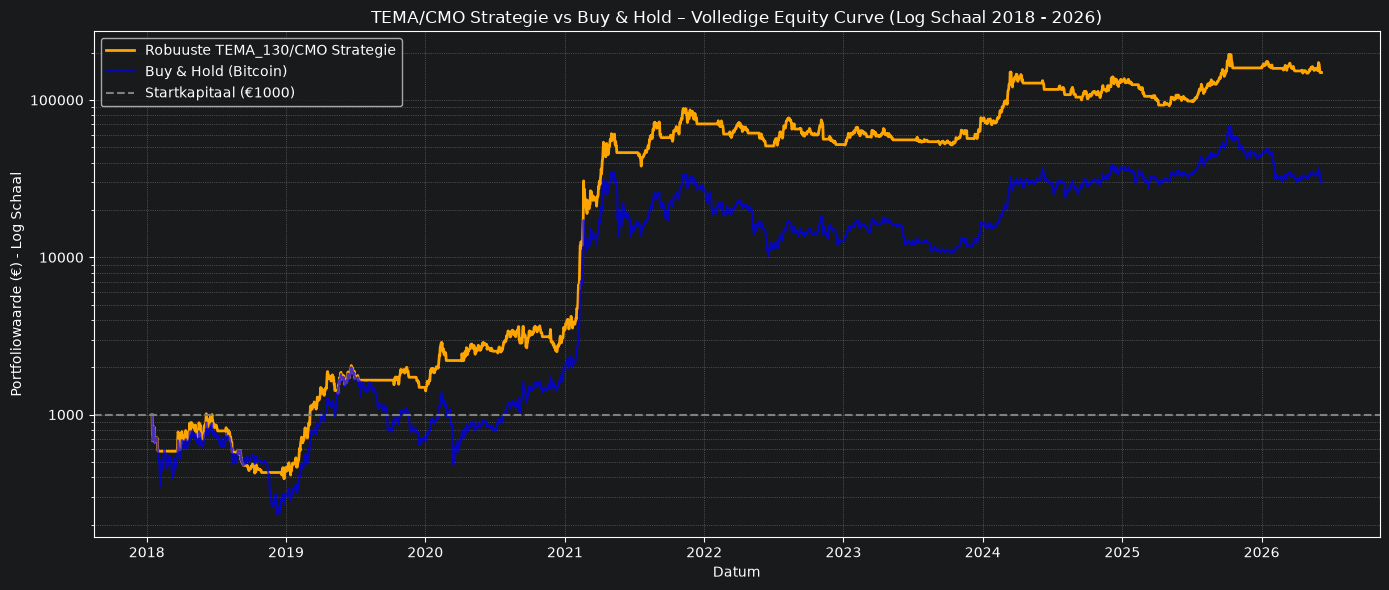

In [4]:
# =========================================================================
# SCHERM 2: TEMA/CMO Strategie vs Buy & Hold op Logaritmische Schaal
# =========================================================================
plt.figure(figsize=(14, 6))

# Lijn 1: Je robuuste, geoptimaliseerde bot (Oranje)
plt.plot(df_equity.index, df_equity["equity"], label="Robuuste TEMA_130/CMO Strategie", color="orange", linewidth=2)

# Lijn 2: Bitcoin Buy & Hold benchmark (Blauw)
plt.plot(df_equity.index, df_equity["buy_hold"], label="Buy & Hold (Bitcoin)", color="blue", linewidth=1.5, alpha=0.7)

# Horizontale hulplijn voor het startkapitaal
plt.axhline(1000, color="gray", linestyle="--", label="Startkapitaal (€1000)")

# MAGIE: Zet de Y-as om naar een logaritmische schaal
plt.yscale('log')

# Netjes formatteren van de Y-as labels (geen vage wetenschappelijke notis)
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.get_major_formatter().set_scientific(False)

# Grafiek opmaak
plt.title("TEMA/CMO Strategie vs Buy & Hold – Volledige Equity Curve (Log Schaal 2018 - 2026)")
plt.xlabel("Datum")
plt.ylabel("Portfoliowaarde (€) - Log Schaal")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6, which="both") # Rasterlijnen voor log-schaal geactiveerd
plt.tight_layout()
plt.show()

In [5]:
# =========================================================================
# STATISTIEKEN GENERATOR VOOR DE ROBUUSTE STRATEGIE
# =========================================================================

# 1. Net PnL berekenen
net_pnl_eur = eind_waarde - 1000.0

# 2. Max Drawdown (Max DD) berekenen over de equity curve
df_stats = pd.DataFrame(portfolio_history)
df_stats['peak'] = df_stats['total_value'].cummax()
df_stats['drawdown'] = (df_stats['total_value'] - df_stats['peak']) / df_stats['peak']
max_dd_pct = df_stats['drawdown'].min() * 100  # Wordt een negatief getal, dus de absolute bodem

# 3. Win% Berekenen op basis van de trades
# We laten de loop nog een keer virtueel kijken naar de winnaars vs verliezers
trade_cash_history = []
cash_temp = 1000.0
bnb_temp = 0.0
in_pos_temp = False
entry_val_temp = 0.0
highest_temp = 0.0
stop_temp = 0.0

wins = 0
losses = 0

for i in range(len(df)):
    row = df.iloc[i]
    p = row['close']
    t = row['TEMA_130']
    c = row['CMO']
    a = row['ATR']

    current_total = cash_temp + (bnb_temp * p)

    if in_pos_temp and p <= stop_temp:
        cash_temp += bnb_temp * p
        bnb_temp = 0.0
        in_pos_temp = False
        if cash_temp < entry_val_temp:
            losses += 1
        else:
            wins += 1
        continue

    if in_pos_temp:
        if p > highest_temp: highest_temp = p
        pot = highest_temp - (3.5 * a)
        if pot > stop_temp: stop_temp = pot

    if not in_pos_temp:
        if p > t and c > 10:
            entry_val_temp = current_total
            bnb_temp = cash_temp / p
            cash_temp = 0.0
            in_pos_temp = True
            highest_temp = p
            stop_temp = p - (3.5 * a)

win_pct = (wins / trade_count * 100) if trade_count > 0 else 0

# 4. Sharpe Ratio berekenen (Gegeneraliseerde dagelijkse returns vs volatiliteit)
# We gaan uit van een risk-free rate van 0% voor crypto benchmarks
df_stats['daily_return'] = df_stats['total_value'].pct_change()
mean_return = df_stats['daily_return'].mean()
std_return = df_stats['daily_return'].std()

# Annualiseren van de Sharpe Ratio (365 handelsdagen voor crypto)
if std_return != 0:
    sharpe_ratio = (mean_return / std_return) * np.sqrt(365)
else:
    sharpe_ratio = 0.0

# =========================================================================
# OUTPUT IN JOUW EXACTE FORMAT (Met Euro-teken omdat je saldo in EUR is)
# =========================================================================
print("📊 STRATEGIE PERFORMANCE DASHBOARD:")
print(f"Net PnL: €{net_pnl_eur:.2f} | Max DD: {abs(max_dd_pct):.2f}% | Trades: {trade_count} | Win%: {win_pct:.2f}% | Sharpe: {sharpe_ratio:.2f}")

📊 STRATEGIE PERFORMANCE DASHBOARD:
Net PnL: €148382.39 | Max DD: 61.41% | Trades: 42 | Win%: 50.00% | Sharpe: 1.19
